### **Clustering**

List of plots:
1. TSNE for accents - s, sp and sa

**Dataset:** Native LJSpeech and SPICOR LJSpeech

**Total entries:** 9648

Each entry has:

1. filename

2. text

3. speaker (native/indian)

**Embeddings:**

- sa (128D) – unstable / exploding

- sp (128D) – stable

- s = [sa; sp] (256D) – stable after filtering

- htext, hbert (variable-length, empty for short audio)



Making libri_accent_spicor.mat dataset

In [ ]:
import scipy.io as sio
import numpy as np
import os

# =========================
# Paths
# =========================
SOURCE_MAT_PATH = "/content/drive/MyDrive/Namrata-IMP-Docs/IIITH/Research/lj_accent_spicor.mat"
OUTPUT_MAT_PATH = "/content/drive/MyDrive/Namrata-IMP-Docs/IIITH/Research/libri_accent_spicor.mat"

# Keys to remove
REMOVE_KEYS = {"s", "sp", "sa", "htext", "hbert"}

# =========================
# Load source MAT file
# =========================
mat_data = sio.loadmat(SOURCE_MAT_PATH)

print("Keys in source MAT file:")
for k in mat_data.keys():
    if not k.startswith("__"):
        print(f"  {k}")

# =========================
# Remove unwanted keys
# =========================
filtered_data = {}

for key, value in mat_data.items():
    # Keep MATLAB internal metadata
    if key.startswith("__"):
        filtered_data[key] = value
        continue

    # Skip unwanted keys
    if key in REMOVE_KEYS:
        print(f"Removing key: {key}")
        continue

    filtered_data[key] = value

# =========================
# Save copied MAT file
# =========================
sio.savemat(OUTPUT_MAT_PATH, filtered_data)

print(f"\nFiltered MAT file saved to: {OUTPUT_MAT_PATH}")

# =========================
# Dataset consistency check
# =========================
print("\nRemaining keys and sample elements:")

# Find a reference length (first valid key)
ref_key = None
ref_len = None

for key, value in filtered_data.items():
    if key.startswith("__"):
        continue
    if isinstance(value, np.ndarray):
        ref_key = key
        ref_len = len(value)
        break

if ref_key is None:
    raise RuntimeError("No valid data arrays found for consistency check.")

print(f"\nReference key: {ref_key}, length = {ref_len}")

for key, value in filtered_data.items():
    if key.startswith("__"):
        continue

    if not isinstance(value, np.ndarray):
        print(f"\nKey: {key} (non-array type: {type(value)})")
        continue

    print(f"\nKey: {key}")
    print(f"  Shape: {value.shape}")

    # Check alignment
    if len(value) != ref_len:
        print("  WARNING: Length mismatch!")

    # Print first 5 elements (aligned by index)
    n_show = min(5, len(value))
    for i in range(n_show):
        elem = value[i]
        if isinstance(elem, np.ndarray):
            print(f"  [{i}] array shape: {elem.shape}")
        else:
            print(f"  [{i}] value: {elem}")


## **Accent - type**

### **LJ Model for accent type**

In [ ]:
import numpy as np
from scipy.io import loadmat

from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt


In [ ]:
path = "/content/drive/MyDrive/Namrata-IMP-Docs/IIITH/Research/lj_accent_spicor.mat"
mat = loadmat(path)

print("==== Keys in .mat file ====")
for k in mat.keys():
    if not k.startswith("__"):
        print(k)


==== Keys in .mat file ====
filename
text
speaker
sa
sp
s
htext
hbert


In [ ]:
def inspect_mat_key(mat, key, max_items=3):
    obj = mat[key]
    print(f"\nKey: {key}")
    print("Type:", type(obj))
    print("Shape:", getattr(obj, "shape", None))
    print("Dtype:", getattr(obj, "dtype", None))

    if isinstance(obj, np.ndarray) and obj.dtype == object:
        print(f"Showing up to {max_items} elements:")
        for i in range(min(max_items, obj.shape[0])):
            try:
                print(f"  [{i}] shape:", obj[i].shape, "dtype:", obj[i].dtype)
            except Exception as e:
                print(f"  [{i}] error:", e)


In [ ]:
for k in mat.keys():
    if not k.startswith("__"):
        inspect_mat_key(mat, k)



Key: filename
Type: <class 'numpy.ndarray'>
Shape: (1, 9468)
Dtype: object
Showing up to 3 elements:
  [0] shape: (9468,) dtype: object

Key: text
Type: <class 'numpy.ndarray'>
Shape: (1, 9468)
Dtype: object
Showing up to 3 elements:
  [0] shape: (9468,) dtype: object

Key: speaker
Type: <class 'numpy.ndarray'>
Shape: (1, 9468)
Dtype: object
Showing up to 3 elements:
  [0] shape: (9468,) dtype: object

Key: sa
Type: <class 'numpy.ndarray'>
Shape: (9468, 128)
Dtype: float32

Key: sp
Type: <class 'numpy.ndarray'>
Shape: (9468, 128)
Dtype: float32

Key: s
Type: <class 'numpy.ndarray'>
Shape: (9468, 256)
Dtype: float32

Key: htext
Type: <class 'numpy.ndarray'>
Shape: (1, 9468)
Dtype: object
Showing up to 3 elements:
  [0] shape: (9468,) dtype: object

Key: hbert
Type: <class 'numpy.ndarray'>
Shape: (1, 9468)
Dtype: object
Showing up to 3 elements:
  [0] shape: (9468,) dtype: object


In [ ]:
# Example (adjust only if inspection shows different names)
s  = mat["s"]
sp = mat["sp"]
sa = mat["sa"]

speaker = mat["speaker"].flatten()


In [ ]:
assert len(s) == len(sp) == len(sa) == len(speaker)
print("Total samples:", len(s))


Total samples: 9468


In [ ]:
def get_valid_indices_dense(*arrays):
    mask = np.ones(arrays[0].shape[0], dtype=bool)

    for X in arrays:
        mask &= np.isfinite(X).all(axis=1)

    return np.where(mask)[0]


In [ ]:
valid_idx = get_valid_indices_dense(s, sp, sa)
print("Valid samples:", len(valid_idx))  # should be close to 9468


Valid samples: 9468


In [ ]:
s_valid  = s[valid_idx]
sp_valid = sp[valid_idx]
sa_valid = sa[valid_idx]

speaker_valid = mat["speaker"][0][valid_idx]


In [ ]:
print(s_valid.shape, sp_valid.shape, sa_valid.shape)
print(len(speaker_valid))


(9468, 256) (9468, 128) (9468, 128)
9468


In [ ]:
speaker_raw = mat["speaker"][0]   # shape (9468,)

speaker_clean = np.array([
    s[0] if isinstance(s, np.ndarray) else s
    for s in speaker_raw
])


In [ ]:
print("Unique speakers:", np.unique(speaker_clean))
print(type(speaker_clean[0]))


Unique speakers: ['indian' 'native']
<class 'numpy.str_'>


In [ ]:
from sklearn.preprocessing import LabelEncoder

enc = LabelEncoder()
accent_id = enc.fit_transform(speaker_clean)

accent_map = dict(enumerate(enc.classes_))
print("Accent mapping:", accent_map)


Accent mapping: {0: np.str_('indian'), 1: np.str_('native')}


In [ ]:
def preprocess_styletts2_embeddings_dense(X, labels, clip_val=5.0, pca_dim=50):
    """
    X      : (N, D) dense embeddings
    labels : (N,)
    """

    # finite check (row-wise)
    finite_mask = np.isfinite(X).all(axis=1)
    X = X[finite_mask]
    labels = labels[finite_mask]

    # clipping
    X = np.clip(X, -clip_val, clip_val)

    # L2 normalization
    X = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-8)

    # PCA to pca_dim
    pca = PCA(
        n_components=min(pca_dim, X.shape[0] - 1),
        random_state=42
    )
    X_pca = pca.fit_transform(X)

    return X_pca, labels


In [ ]:
s_p,  y = preprocess_styletts2_embeddings_dense(s_valid,  accent_id)
sp_p, _ = preprocess_styletts2_embeddings_dense(sp_valid, accent_id)
sa_p, _ = preprocess_styletts2_embeddings_dense(sa_valid, accent_id)

print(s_p.shape, sp_p.shape, sa_p.shape)
print(len(y))


(9468, 50) (9468, 50) (9468, 50)
9468


In [ ]:
def plot_pca_2d_labels(X, y, title, label_map, legend_title="Label"):
    X_2d = PCA(n_components=2, random_state=42).fit_transform(X)

    plt.figure(figsize=(6, 6))
    for lab in np.unique(y):
        idx = y == lab
        plt.scatter(
            X_2d[idx, 0],
            X_2d[idx, 1],
            label=label_map[lab],
            s=15
        )

    plt.title(title)
    plt.legend(title=legend_title)
    plt.tight_layout()
    plt.show()


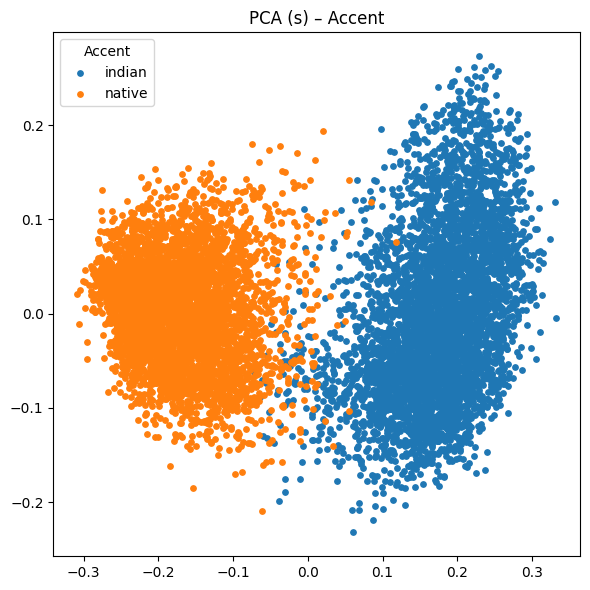

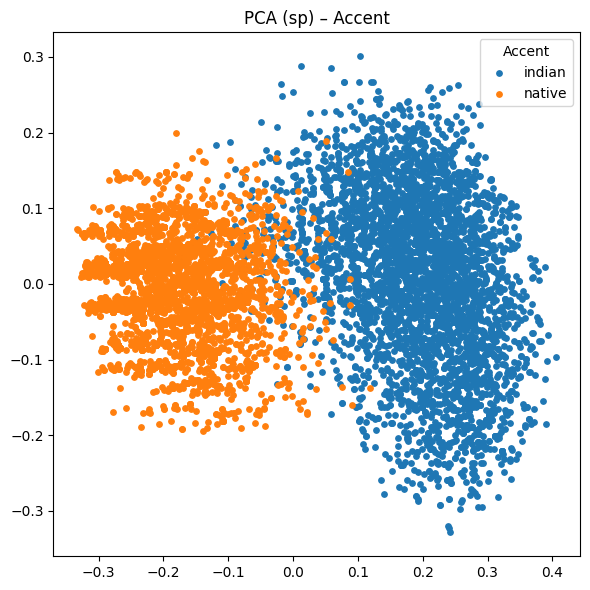

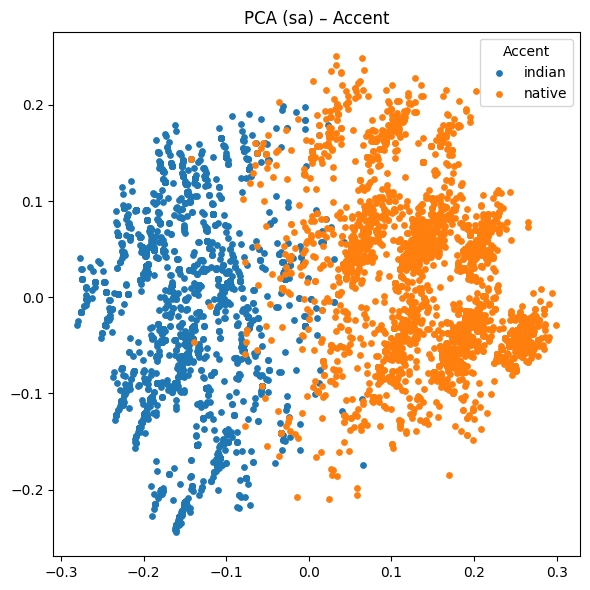

In [ ]:
plot_pca_2d_labels(s_p,  y, "PCA (s) – Accent",  accent_map, legend_title="Accent")
plot_pca_2d_labels(sp_p, y, "PCA (sp) – Accent", accent_map, legend_title="Accent")
plot_pca_2d_labels(sa_p, y, "PCA (sa) – Accent", accent_map, legend_title="Accent")


In [ ]:
def plot_tsne_2d_labels(X, y, title, label_map, legend_title="Label", perplexity=30):
    X_2d = TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        random_state=42
    ).fit_transform(X)

    plt.figure(figsize=(6, 6))
    for lab in np.unique(y):
        idx = y == lab
        plt.scatter(
            X_2d[idx, 0],
            X_2d[idx, 1],
            label=label_map[lab],
            s=15
        )

    plt.title(title)
    plt.legend(title=legend_title)
    plt.tight_layout()
    plt.show()


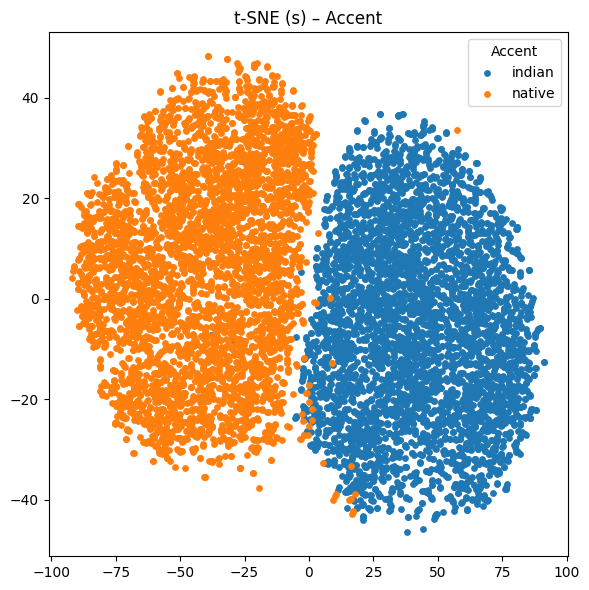

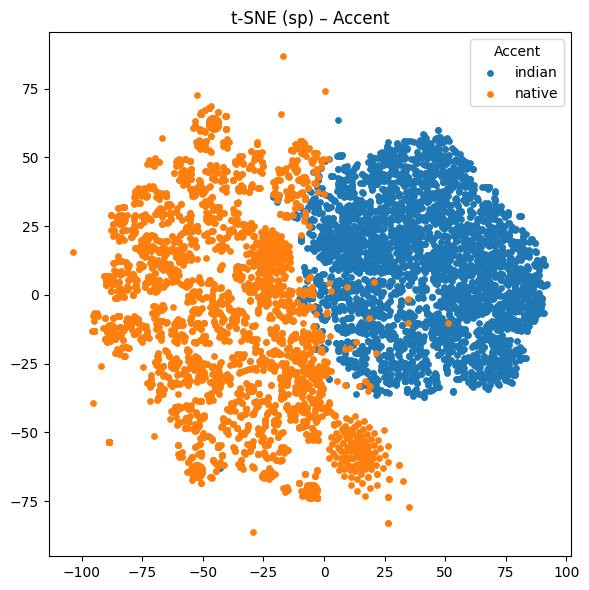

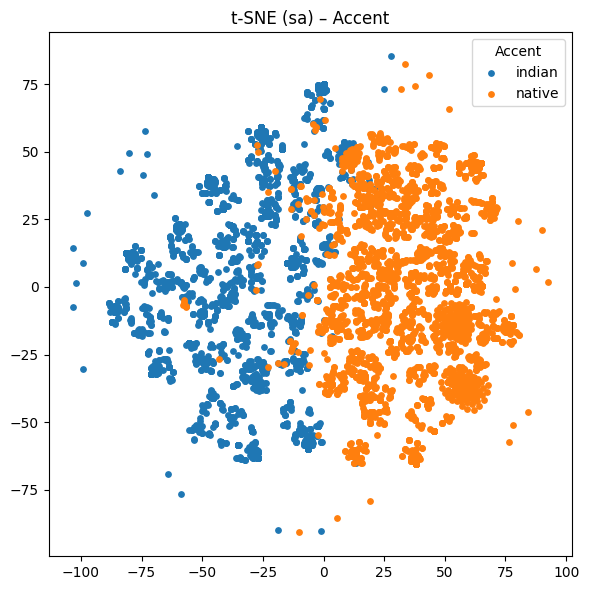

In [ ]:
plot_tsne_2d_labels(s_p,  y, "t-SNE (s) – Accent",  accent_map, legend_title="Accent")
plot_tsne_2d_labels(sp_p, y, "t-SNE (sp) – Accent", accent_map, legend_title="Accent")
plot_tsne_2d_labels(sa_p, y, "t-SNE (sa) – Accent", accent_map, legend_title="Accent")


perplexity changed - 5, 10, 20, 40, 50

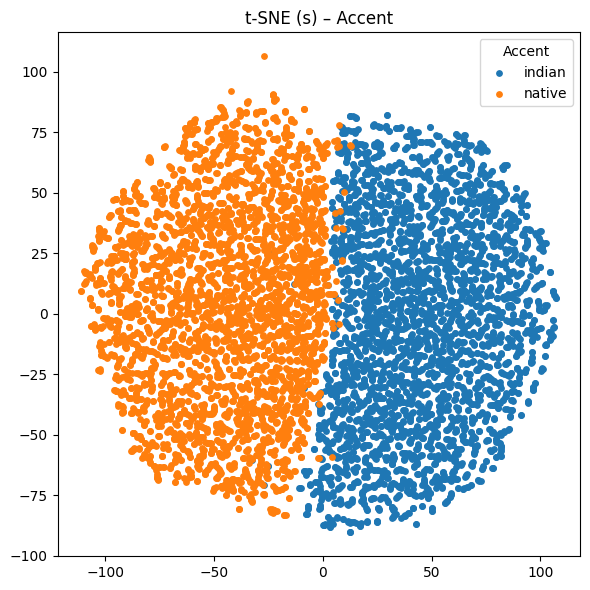

In [ ]:
def plot_tsne_2d_labels(X, y, title, label_map, legend_title="Label", perplexity=5):
    X_2d = TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        random_state=42
    ).fit_transform(X)

    plt.figure(figsize=(6, 6))
    for lab in np.unique(y):
        idx = y == lab
        plt.scatter(
            X_2d[idx, 0],
            X_2d[idx, 1],
            label=label_map[lab],
            s=15
        )

    plt.title(title)
    plt.legend(title=legend_title)
    plt.tight_layout()
    plt.show()

plot_tsne_2d_labels(s_p,  y, "t-SNE (s) – Accent",  accent_map, legend_title="Accent")


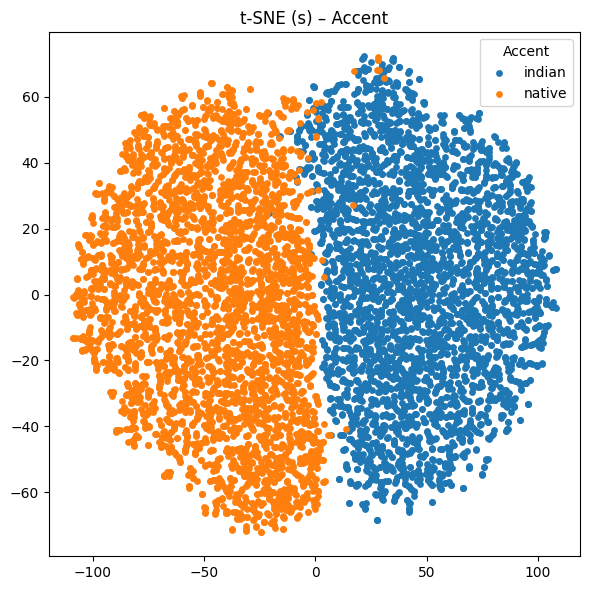

In [ ]:
def plot_tsne_2d_labels(X, y, title, label_map, legend_title="Label", perplexity=10):
    X_2d = TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        random_state=42
    ).fit_transform(X)

    plt.figure(figsize=(6, 6))
    for lab in np.unique(y):
        idx = y == lab
        plt.scatter(
            X_2d[idx, 0],
            X_2d[idx, 1],
            label=label_map[lab],
            s=15
        )

    plt.title(title)
    plt.legend(title=legend_title)
    plt.tight_layout()
    plt.show()

plot_tsne_2d_labels(s_p,  y, "t-SNE (s) – Accent",  accent_map, legend_title="Accent")


In [ ]:
def plot_tsne_2d_labels(X, y, title, label_map, legend_title="Label", perplexity=20):
    X_2d = TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        random_state=42
    ).fit_transform(X)

    plt.figure(figsize=(6, 6))
    for lab in np.unique(y):
        idx = y == lab
        plt.scatter(
            X_2d[idx, 0],
            X_2d[idx, 1],
            label=label_map[lab],
            s=15
        )

    plt.title(title)
    plt.legend(title=legend_title)
    plt.tight_layout()
    plt.show()

plot_tsne_2d_labels(s_p,  y, "t-SNE (s) – Accent",  accent_map, legend_title="Accent")


KeyboardInterrupt: 

In [ ]:
def plot_tsne_2d_labels(X, y, title, label_map, legend_title="Label", perplexity=40):
    X_2d = TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        random_state=42
    ).fit_transform(X)

    plt.figure(figsize=(6, 6))
    for lab in np.unique(y):
        idx = y == lab
        plt.scatter(
            X_2d[idx, 0],
            X_2d[idx, 1],
            label=label_map[lab],
            s=15
        )

    plt.title(title)
    plt.legend(title=legend_title)
    plt.tight_layout()
    plt.show()

plot_tsne_2d_labels(s_p,  y, "t-SNE (s) – Accent",  accent_map, legend_title="Accent")


In [ ]:
def plot_tsne_2d_labels(X, y, title, label_map, legend_title="Label", perplexity=50):
    X_2d = TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        random_state=42
    ).fit_transform(X)

    plt.figure(figsize=(6, 6))
    for lab in np.unique(y):
        idx = y == lab
        plt.scatter(
            X_2d[idx, 0],
            X_2d[idx, 1],
            label=label_map[lab],
            s=15
        )

    plt.title(title)
    plt.legend(title=legend_title)
    plt.tight_layout()
    plt.show()

plot_tsne_2d_labels(s_p,  y, "t-SNE (s) – Accent",  accent_map, legend_title="Accent")


In [ ]:
print("Silhouette Scores (Accent separation)")
print("s  :", silhouette_score(s_p,  y))
print("sp :", silhouette_score(sp_p, y))
print("sa :", silhouette_score(sa_p, y))


Silhouette Scores (Accent separation)
s  : 0.24798901
sp : 0.23875576
sa : 0.25603756


### **Libri Model for accent type**

In [ ]:
import numpy as np
from scipy.io import loadmat

from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt


In [ ]:
path = "/content/drive/MyDrive/Namrata-IMP-Docs/IIITH/Research/libri_accent_spicor.mat"
mat = loadmat(path)

print("==== Keys in .mat file ====")
for k in mat.keys():
    if not k.startswith("__"):
        print(k)


==== Keys in .mat file ====
filename
text
speaker
sa
sp
s
htext
hbert


In [ ]:
def inspect_mat_key(mat, key, max_items=3):
    obj = mat[key]
    print(f"\nKey: {key}")
    print("Type:", type(obj))
    print("Shape:", getattr(obj, "shape", None))
    print("Dtype:", getattr(obj, "dtype", None))

    if isinstance(obj, np.ndarray) and obj.dtype == object:
        print(f"Showing up to {max_items} elements:")
        for i in range(min(max_items, obj.shape[0])):
            try:
                print(f"  [{i}] shape:", obj[i].shape, "dtype:", obj[i].dtype)
            except Exception as e:
                print(f"  [{i}] error:", e)


In [ ]:
for k in mat.keys():
    if not k.startswith("__"):
        inspect_mat_key(mat, k)



Key: filename
Type: <class 'numpy.ndarray'>
Shape: (1, 9468)
Dtype: object
Showing up to 3 elements:
  [0] shape: (9468,) dtype: object

Key: text
Type: <class 'numpy.ndarray'>
Shape: (1, 9468)
Dtype: object
Showing up to 3 elements:
  [0] shape: (9468,) dtype: object

Key: speaker
Type: <class 'numpy.ndarray'>
Shape: (1, 9468)
Dtype: object
Showing up to 3 elements:
  [0] shape: (9468,) dtype: object

Key: sa
Type: <class 'numpy.ndarray'>
Shape: (9468, 128)
Dtype: float32

Key: sp
Type: <class 'numpy.ndarray'>
Shape: (9468, 128)
Dtype: float32

Key: s
Type: <class 'numpy.ndarray'>
Shape: (9468, 256)
Dtype: float32

Key: htext
Type: <class 'numpy.ndarray'>
Shape: (1, 9468)
Dtype: object
Showing up to 3 elements:
  [0] shape: (9468,) dtype: object

Key: hbert
Type: <class 'numpy.ndarray'>
Shape: (1, 9468)
Dtype: object
Showing up to 3 elements:
  [0] shape: (9468,) dtype: object


In [ ]:
# Example (adjust only if inspection shows different names)
s  = mat["s"]
sp = mat["sp"]
sa = mat["sa"]

speaker = mat["speaker"].flatten()


In [ ]:
assert len(s) == len(sp) == len(sa) == len(speaker)
print("Total samples:", len(s))


Total samples: 9468


In [ ]:
def get_valid_indices_dense(*arrays):
    mask = np.ones(arrays[0].shape[0], dtype=bool)

    for X in arrays:
        mask &= np.isfinite(X).all(axis=1)

    return np.where(mask)[0]


In [ ]:
valid_idx = get_valid_indices_dense(s, sp, sa)
print("Valid samples:", len(valid_idx))  # should be close to 9468


Valid samples: 9468


In [ ]:
s_valid  = s[valid_idx]
sp_valid = sp[valid_idx]
sa_valid = sa[valid_idx]

speaker_valid = mat["speaker"][0][valid_idx]


In [ ]:
print(s_valid.shape, sp_valid.shape, sa_valid.shape)
print(len(speaker_valid))


(9468, 256) (9468, 128) (9468, 128)
9468


In [ ]:
speaker_raw = mat["speaker"][0]   # shape (9468,)

speaker_clean = np.array([
    s[0] if isinstance(s, np.ndarray) else s
    for s in speaker_raw
])


In [ ]:
print("Unique speakers:", np.unique(speaker_clean))
print(type(speaker_clean[0]))


Unique speakers: ['indian' 'native']
<class 'numpy.str_'>


In [ ]:
from sklearn.preprocessing import LabelEncoder

enc = LabelEncoder()
accent_id = enc.fit_transform(speaker_clean)

accent_map = dict(enumerate(enc.classes_))
print("Accent mapping:", accent_map)


Accent mapping: {0: np.str_('indian'), 1: np.str_('native')}


In [ ]:
def preprocess_styletts2_embeddings_dense(X, labels, clip_val=5.0, pca_dim=50):
    """
    X      : (N, D) dense embeddings
    labels : (N,)
    """

    # finite check (row-wise)
    finite_mask = np.isfinite(X).all(axis=1)
    X = X[finite_mask]
    labels = labels[finite_mask]

    # clipping
    X = np.clip(X, -clip_val, clip_val)

    # L2 normalization
    X = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-8)

    # PCA to pca_dim
    pca = PCA(
        n_components=min(pca_dim, X.shape[0] - 1),
        random_state=42
    )
    X_pca = pca.fit_transform(X)

    return X_pca, labels


In [ ]:
s_p,  y = preprocess_styletts2_embeddings_dense(s_valid,  accent_id)
sp_p, _ = preprocess_styletts2_embeddings_dense(sp_valid, accent_id)
sa_p, _ = preprocess_styletts2_embeddings_dense(sa_valid, accent_id)

print(s_p.shape, sp_p.shape, sa_p.shape)
print(len(y))


(9468, 50) (9468, 50) (9468, 50)
9468


In [ ]:
def plot_pca_2d_labels(X, y, title, label_map, legend_title="Label"):
    X_2d = PCA(n_components=2, random_state=42).fit_transform(X)

    plt.figure(figsize=(6, 6))
    for lab in np.unique(y):
        idx = y == lab
        plt.scatter(
            X_2d[idx, 0],
            X_2d[idx, 1],
            label=label_map[lab],
            s=15
        )

    plt.title(title)
    plt.legend(title=legend_title)
    plt.tight_layout()
    plt.show()


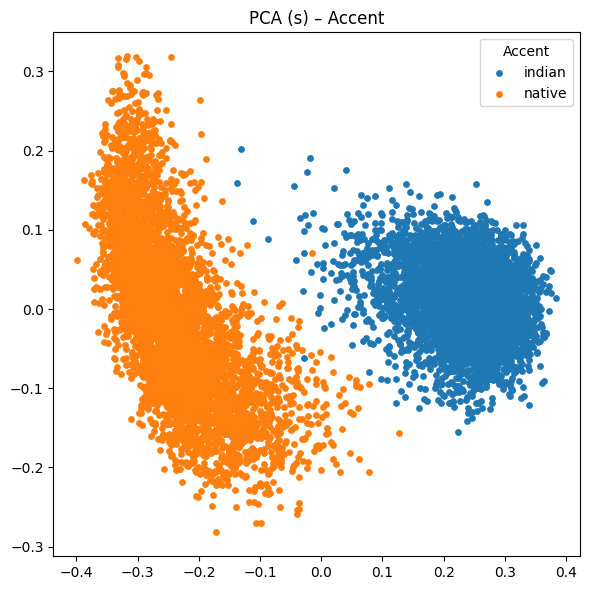

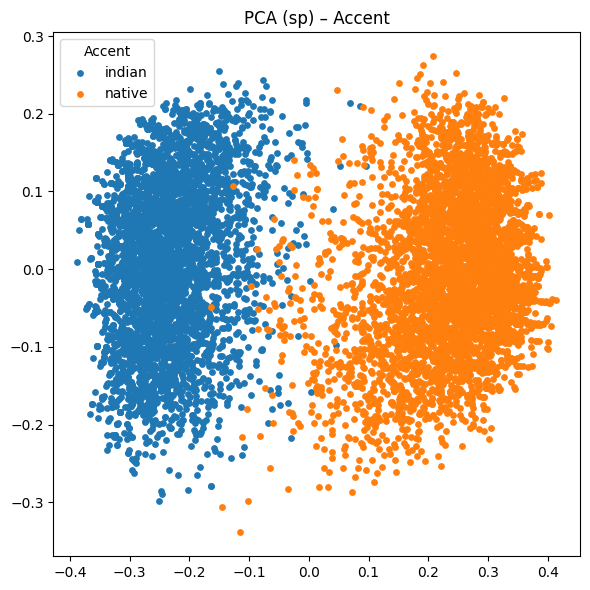

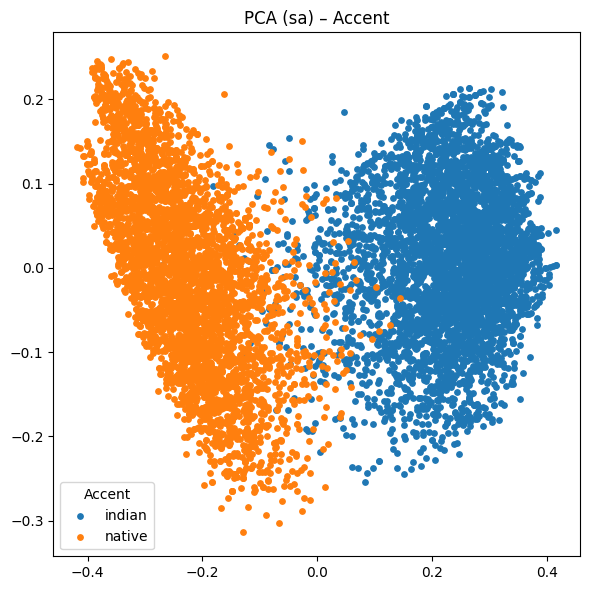

In [ ]:
plot_pca_2d_labels(s_p,  y, "PCA (s) – Accent",  accent_map, legend_title="Accent")
plot_pca_2d_labels(sp_p, y, "PCA (sp) – Accent", accent_map, legend_title="Accent")
plot_pca_2d_labels(sa_p, y, "PCA (sa) – Accent", accent_map, legend_title="Accent")


In [ ]:
def plot_tsne_2d_labels(X, y, title, label_map, legend_title="Label", perplexity=30):
    X_2d = TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        random_state=42
    ).fit_transform(X)

    plt.figure(figsize=(6, 6))
    for lab in np.unique(y):
        idx = y == lab
        plt.scatter(
            X_2d[idx, 0],
            X_2d[idx, 1],
            label=label_map[lab],
            s=15
        )

    plt.title(title)
    plt.legend(title=legend_title)
    plt.tight_layout()
    plt.show()


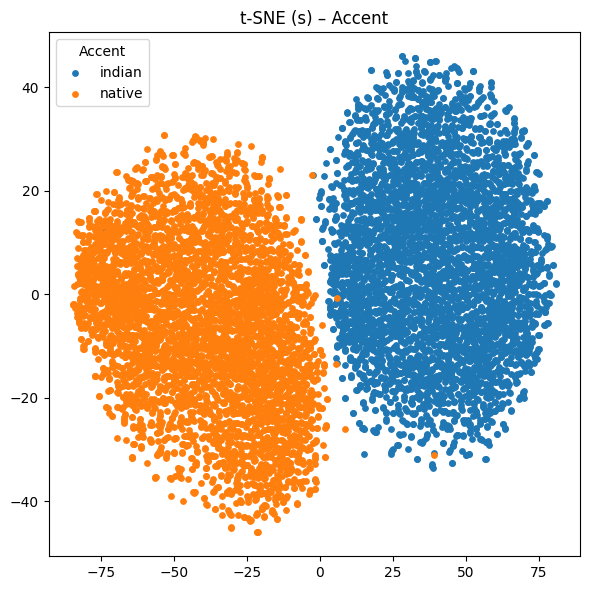

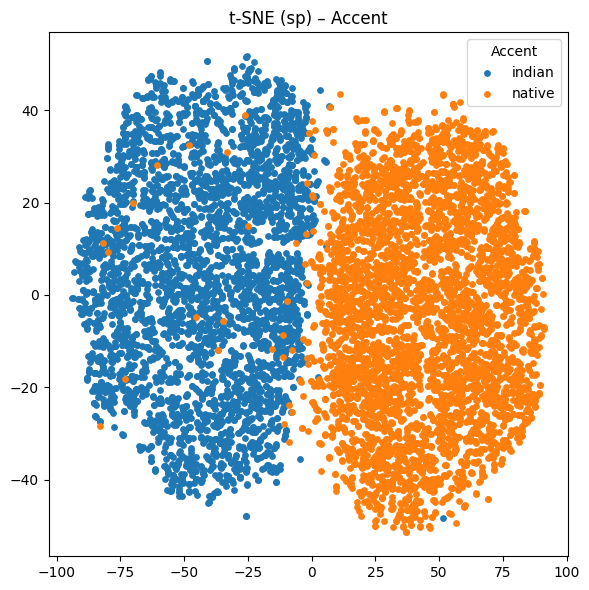

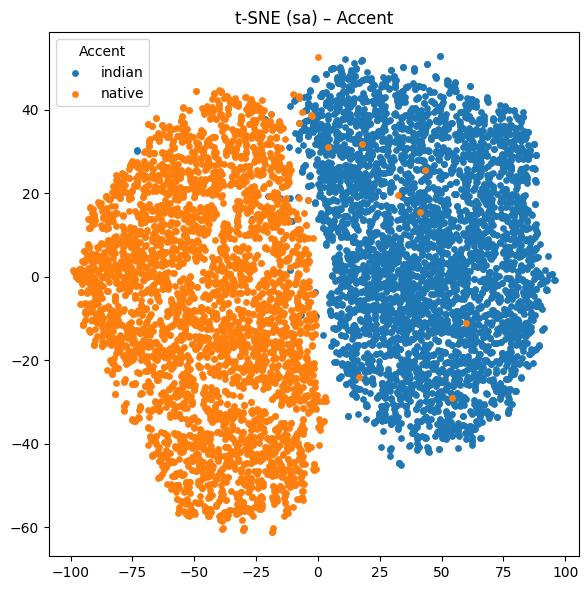

In [ ]:
plot_tsne_2d_labels(s_p,  y, "t-SNE (s) – Accent",  accent_map, legend_title="Accent")
plot_tsne_2d_labels(sp_p, y, "t-SNE (sp) – Accent", accent_map, legend_title="Accent")
plot_tsne_2d_labels(sa_p, y, "t-SNE (sa) – Accent", accent_map, legend_title="Accent")


In [ ]:
print("Silhouette Scores (Accent separation)")
print("s  :", silhouette_score(s_p,  y))
print("sp :", silhouette_score(sp_p, y))
print("sa :", silhouette_score(sa_p, y))


Silhouette Scores (Accent separation)
s  : 0.29191443
sp : 0.28571424
sa : 0.2598705
